# 7.4. 프로젝트 1 — 1차원 Schrödinger 방정식 solver

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import hbar, m_e, e, u, h, c


def solve_1d(V, x, mass, periodic=False):
    """
    V        : 각 격자점에서의 퍼텐셜
    x        : 격자점
    mass     : 질량, 또는 회전 문제에서는 관성모멘트
    periodic : True면 주기적 경계조건 (고리 문제)

    반환값   : 에너지 (J), 파동함수 (열 방향으로 psi[:, n])
    """
    N = len(x)
    dx = x[1] - x[0]

    D2 = (-2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)) / dx**2
    if periodic:
        D2[0, -1] = D2[-1, 0] = 1 / dx**2

    H = -(hbar**2) / (2 * mass) * D2 + np.diag(V)
    E, psi = np.linalg.eigh(H)

    return E, psi / np.sqrt(dx)

In [2]:
N = 2000

# (1) 무한 우물
L = 1e-9
x = np.linspace(0, L, N + 2)[1:-1]
E, psi = solve_1d(np.zeros(N), x, m_e)

print("=== 무한 우물 (L = 1 nm) ===")
for n in range(1, 4):
    exact = n**2 * h**2 / (8 * m_e * L**2) / e
    print(f"n = {n}: {E[n-1]/e:9.5f} eV   (해석해 {exact:.5f})")

# (2) 조화진동자
k_f, mu = 572.0, 0.504 * u
omega = np.sqrt(k_f / mu)
xh = np.linspace(-5e-11, 5e-11, N + 2)[1:-1]
E, psi = solve_1d(0.5 * k_f * xh**2, xh, mu)

print("\n=== 조화진동자 (H2) ===")
for v in range(3):
    exact = (v + 0.5) * hbar * omega / e
    print(f"v = {v}: {E[v]/e:9.5f} eV   (해석해 {exact:.5f})")

# (3) 고리
r = 1e-10
I = m_e * r**2
phi = np.linspace(0, 2 * np.pi, 400, endpoint=False)  # 끝점 제외가 중요
E, psi = solve_1d(np.zeros(len(phi)), phi, I, periodic=True)

print("\n=== 고리 (r = 1 A) ===")
for i, m in enumerate([0, 1, -1, 2, -2]):
    exact = m**2 * hbar**2 / (2 * I) / e
    print(f"{i}번째: {E[i]/e:9.5f} eV   (m={m}, 해석해 {exact:.5f})")

=== 무한 우물 (L = 1 nm) ===
n = 1:   0.37603 eV   (해석해 0.37603)
n = 2:   1.50412 eV   (해석해 1.50412)
n = 3:   3.38427 eV   (해석해 3.38427)

=== 조화진동자 (H2) ===
v = 0:   0.27208 eV   (해석해 0.27208)
v = 1:   0.81624 eV   (해석해 0.81624)
v = 2:   1.36047 eV   (해석해 1.36039)

=== 고리 (r = 1 A) ===
0번째:  -0.00000 eV   (m=0, 해석해 0.00000)
1번째:   3.80990 eV   (m=1, 해석해 3.80998)
2번째:   3.80990 eV   (m=-1, 해석해 3.80998)
3번째:  15.23868 eV   (m=2, 해석해 15.23993)
4번째:  15.23868 eV   (m=-2, 해석해 15.23993)


In [3]:
def plot_levels(ax, x, V, E, psi, n_levels=4, scale=0.2, xunit=1e9):
    ax.plot(x * xunit, V / e, color="black", lw=3)
    span = (E[n_levels] - E[0]) / e

    for k in range(n_levels):
        f = psi[:, k]
        if f[np.argmax(np.abs(f))] < 0:
            f = -f
        ax.hlines(E[k] / e, x[0] * xunit, x[-1] * xunit, color="gray", lw=1, ls=":")
        ax.plot(x * xunit, E[k] / e + scale * span * f / np.abs(f).max(), lw=2)

    ax.set_ylim(min(0, V.min() / e) - 0.1 * span, E[n_levels] / e)
    ax.set_xlabel("x (nm)")
    ax.set_ylabel("E (eV)")

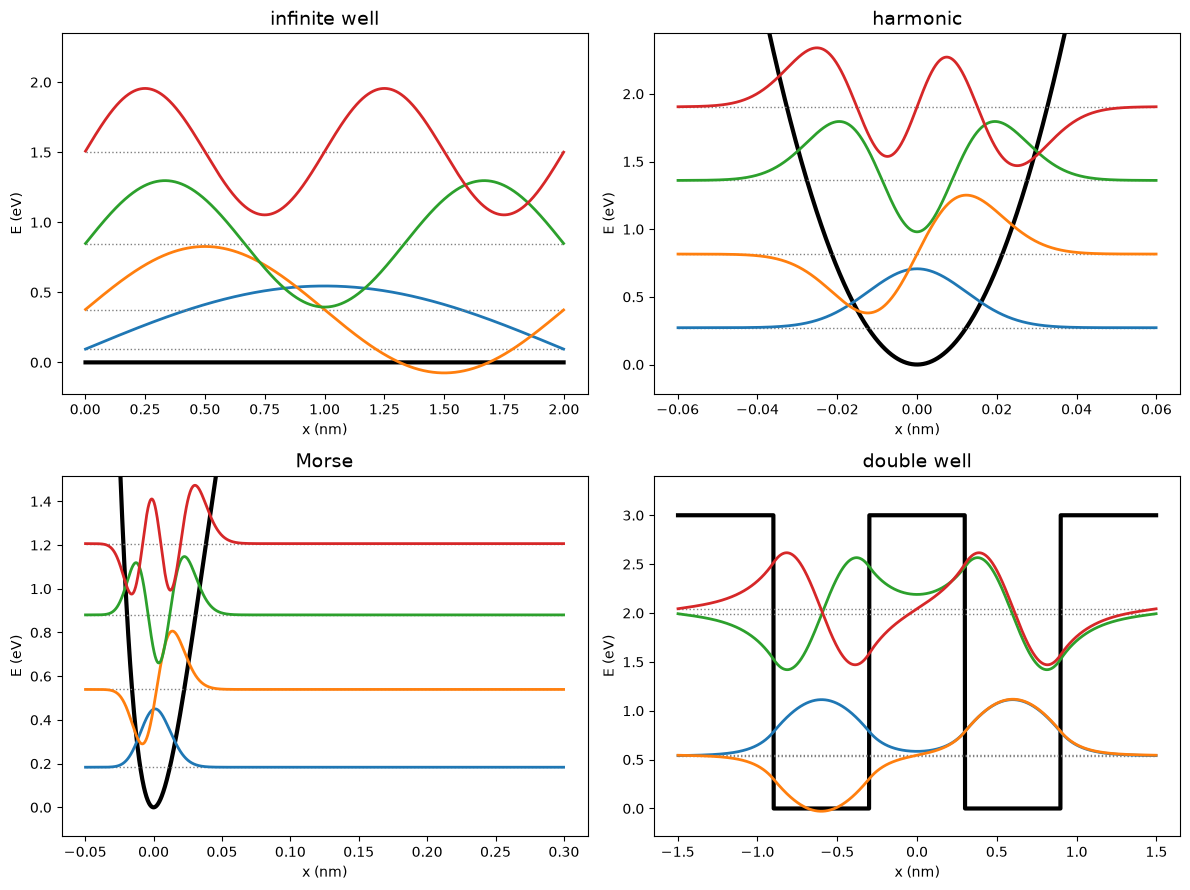

In [4]:
N = 1500
cases = []

# 무한 우물
L = 2e-9
x1 = np.linspace(0, L, N + 2)[1:-1]
E1, p1 = solve_1d(np.zeros(N), x1, m_e)
cases.append(("infinite well", x1, np.zeros(N), E1, p1))

# 조화진동자
x2 = np.linspace(-6e-11, 6e-11, N + 2)[1:-1]
V2 = 0.5 * 572.0 * x2**2
E2, p2 = solve_1d(V2, x2, 0.504 * u)
cases.append(("harmonic", x2, V2, E2, p2))

# Morse 퍼텐셜
De, a = 37244 * 100 * h * c, 1.868e10
mu_hcl = 1.008 * 34.969 / (1.008 + 34.969) * u
x3 = np.linspace(-0.5e-10, 3e-10, N + 2)[1:-1]
V3 = De * (1 - np.exp(-a * x3)) ** 2
E3, p3 = solve_1d(V3, x3, mu_hcl)
cases.append(("Morse", x3, V3, E3, p3))

# 이중 우물
x4 = np.linspace(-1.5e-9, 1.5e-9, N + 2)[1:-1]
V4 = np.where(np.abs(np.abs(x4) - 0.6e-9) < 0.3e-9, 0.0, 3.0 * e)
E4, p4 = solve_1d(V4, x4, m_e)
cases.append(("double well", x4, V4, E4, p4))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (title, x, V, E, psi) in zip(axes.ravel(), cases):
    plot_levels(ax, x, V, E, psi)
    ax.set_title(title, fontsize=14)

plt.tight_layout()
plt.show()